In [22]:
import sys
if "tf_env" not in sys.executable:
    print("/n环境配置错误!!!/n")
    print(sys.executable)
else:
    print("环境配置正常")

环境配置正常


In [23]:
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt 
from matplotlib import rcParams # 字体配置,支持中文
rcParams['font.family'] = 'SimHei'
rcParams['axes.unicode_minus'] = False  # 解决负号不显示的问题

import tensorflow as tf

In [24]:
# ===== 2. 梯度与微分 =====
'''
1. 梯度就是导数,在机器学习中,梯度指的是损失函数对模型参数(如权重)的导数
2. 自动微分,可以追踪操作并且计算梯度
'''

'\n1. 梯度就是导数,在机器学习中,梯度指的是损失函数对模型参数(如权重)的导数\n2. 自动微分,可以追踪操作并且计算梯度\n'

In [25]:
def f(x):
    return x**2

In [26]:
# 例1:计算梯度
x = tf.Variable(3.0)    # 必须是float,必须是Variable而不是tensor # type:ignore , TensorFlow 只对浮点数计算梯度。
# 使用GradientTape自动计算梯度
with tf.GradientTape() as tape:
    y = f(x) # 正向计算 x**2

# 计算fx对x的梯度(导数)
grade = tape.gradient(y,x)
print(grade.numpy()) # type:ignore

6.0


In [27]:
# ========= 例2: 简单的线性模型 =========
# 目标: 预测: fx = w * x + b (w:权重 , b:偏置)

In [28]:
# 1. 制造样本数据

# 正确的权重和偏置:
TRUE_W = 3.0
TRUE_B = 2.0
NUM_EXAMPLES = 201 # 201 数据量

# 真实函数
def f(x):
    return x * TRUE_W + TRUE_B

# 建立x数据库(样本,等会还要给y_data加上噪音)
x_data = tf.linspace(-2,2,NUM_EXAMPLES) 
x_data = tf.cast(x_data , tf.float32) # 类型转换

# 生成噪声数据
noise = tf.random.normal(shape=[NUM_EXAMPLES])
# print(noise)

# 建立y数据库,需要加上噪音
y_data = f(x_data) + noise

In [29]:
# 2. 定义模型

class My_model_Keras(tf.keras.Model):
    def __init__(self, **kwargs) -> None:
        super().__init__(**kwargs)  # super().原参数 调用原父类的 (super().pro)
        # 权重
        self.w = tf.Variable(5.0 , name='weight') # type:ignore , 5.0是假定值,实际应用中需要随机设置
        # 偏置
        self.b = tf.Variable(0.0 , name='bias')   # type:ignore , 0.0是假定值
    
    def call(self, x):   # call方法等价于类的return值
        return self.w * x + self.b  

# 定义损失函数(均方误差)
def loss(target_y , predict_y):
    return tf.reduce_mean(tf.square(target_y - predict_y))

# 定义训练模型
def train(model , x , y , learning_rate):
    with tf.GradientTape() as t:
        # GradientTape自动跟踪可训练变量
        current_loss = loss(y_data , model(x))  # y_data是现实数据(就是理想的x加上了noise) , model(x)是预测数据
    # 使用GradientTape计算关于权重w和偏置b
    # print("current_loss = :",current_loss)
    dw , db = t.gradient(current_loss , [model.w , model.b])  # ?有疑问

    # 减去按学习率缩放的梯度(更新参数)
    model.w.assign_sub(learning_rate * dw)  # 让变量减去某个值，并把结果重新保存回变量,其实就是add的反义词
    model.b.assign_sub(learning_rate * db)


# 实例化模型
keras_model = My_model_Keras()
print("模型参数:",keras_model.variables) # 输出模型参数

# 训练10轮
epochs = range(10)
# 定义一个报告函数
def report(model , loss):
    return f"w = {model.w.numpy():1.2f} , b = {model.b.numpy():1.2f} , loss={loss:2.5f}"

# 定义一个训练循环
def train_loop(model , x , y):
    for epoch in epochs:
        # 训练模型
        train(model , x , y , learning_rate=0.1)
        # 储存loss
        current_loss = loss(y,model(x))
        print(f"Epoch {epoch:2d}:{report(model , current_loss)}")

current_loss = loss(y_data , keras_model(x))
print('开始')
print('' , report(keras_model , current_loss))

train_loop(keras_model , x_data , y_data)

模型参数: []
开始
 w = 5.00 , b = 0.00 , loss=179.48535
Epoch  0:w = 4.44 , b = 0.42 , loss=6.77201
Epoch  1:w = 4.04 , b = 0.75 , loss=4.35090
Epoch  2:w = 3.74 , b = 1.02 , loss=2.95247
Epoch  3:w = 3.53 , b = 1.23 , loss=2.13813
Epoch  4:w = 3.37 , b = 1.40 , loss=1.66002
Epoch  5:w = 3.25 , b = 1.54 , loss=1.37701
Epoch  6:w = 3.17 , b = 1.64 , loss=1.20816
Epoch  7:w = 3.11 , b = 1.73 , loss=1.10665
Epoch  8:w = 3.06 , b = 1.80 , loss=1.04518
Epoch  9:w = 3.03 , b = 1.86 , loss=1.00771


In [30]:
# # 3-1. 参数变化可视化

# plt.plot(epochs , weights , label="模型演变权重" , color="blue")
# plt.plot(epochs , [TRUE_W]*len(epochs) , label="真实权重" , color="red")

# plt.plot(epochs , biases , label="模型演变偏置" , color="blue")
# plt.plot(epochs , [TRUE_B]*len(epochs) , label="真实偏置" , color="red")

# plt.legend()
# plt.show()

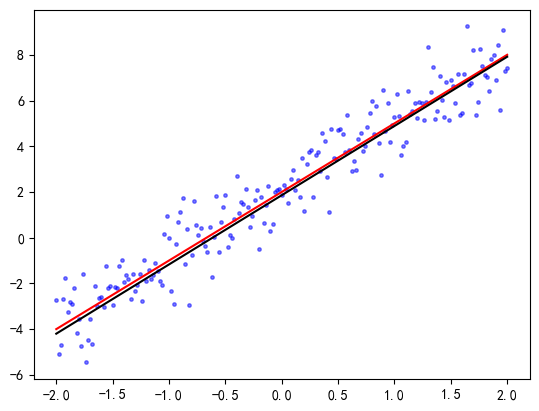

In [31]:
# 3-2. 绘制图像:散点图
plt.scatter(x_data , y_data,color='blue',alpha=0.5,s=6)
# 绘制预测值和真实值
plt.plot(x_data , f(x_data),color='red'    ,label="真实值")   # 真实值回归线
plt.plot(x_data,keras_model(x_data),color='black',label="预测值")   # 预测值回归线
plt.show()